<!--TABLE OF CONTENTS-->
Contents:
- [LLMs in Practice](#LLMs-in-Practice)
  - [Basic LLM Interaction](#Basic-LLM-Interaction)
    - [Managing Prompts with Prompt Templates](#Managing-Prompts-with-Prompt-Templates)
  - [Tokenization Economics](#Tokenization-Economics)
  - [Building a RAG Pipeline](#Building-a-RAG-Pipeline)
    - [Chunking and embedding](#Chunking-and-embedding)
    - [Generation](#Generation)
  - [Embedding Space and Semantic Search Properties](#Embedding-Space-and-Semantic-Search-Properties)
  - [Prompt Engineering Experiments](#Prompt-Engineering-Experiments)
  - [Fine-Tuning with LoRA](#Fine-Tuning-with-LoRA)
  - [Key points](#Key-points)

# LLMs in Practice


It is recommended to run thi notebook in Google Colab.

Install the following:

`pip install tiktoken sentence-transformers transformers peft datasets accelerate python-dotenv pypdf chromadb langchain langchain-text-splitters langchain-community langchain-chroma langchain-google-genai`

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import os
import requests
from dotenv import load_dotenv
from sklearn.metrics.pairwise import cosine_similarity
from dotenv import load_dotenv
import warnings; warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False})

In [1]:
#!pip install tiktoken langchain_google_genai sentence-transformers transformers peft datasets accelerate python-dotenv pypdf chromadb langchain langchain-text-splitters langchain-community langchain-chroma langchain-huggingface

## Basic LLM Interaction

In the previous notebooks, every operation could either be run locally or on Colab using open-source models downloaded directly from Hugging Face.
In this notebook we want to use a more capable model, but running a larger model locally requires significant GPU memory — for example Llama 3.1 8B needs roughly 16GB of memory at float16, which is not available in a standard Colab session. Rather than running the model ourselves, we call a hosted API where the model runs on the provider's servers and we send our prompt over the internet. This is the API model discussed: we pay per token (or use a free tier) in exchange for not having to manage the infrastructure ourselves. The API key is simply how the provider identifies who is making the request and tracks usage against the free tier limits.

We will use models from Google via the Google AI Studio API, which requires a Google account to get an API key at aistudio.google.com.  [Here](https://ai.google.dev/gemini-api/docs/pricing) is the pricing page. We will use the free tier but it has limits.
Setup (one-time):

- Go to aistudio.google.com and sign in with your Google account
- Click "Get API key" and create a new key
- Add it to your .env file as GOOGLE_API_KEY=your_key_here

A .env file is a simple text file that sits in the project folder and stores sensitive configuration values — like API keys and passwords. The reason for using it rather than pasting the key directly into the code is security. If we hardcode an API key in a notebook and share that notebook with someone, upload it to GitHub, or submit it as coursework, the private key is exposed.
We will use load_dotenv function which reads the key-value pairs from the .env file (which should be located in the same directory as the script, or a parent directory) and loads them into the environment variables of the operating system process where the Python script is currently running.

We can see the list of available models within the free tier. We will be using some from the this list.

In [3]:
from dotenv import load_dotenv
load_dotenv()
from google import genai

client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))

for m in client.models.list():
    print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gem

LangChain is a framework for developing applications powered by Large Language Models.  It provides standard interfaces, integrations with various LLM providers, and useful building blocks (like prompt templates, chains, agents, and memory) to create more complex and capable AI applications. Here is a [list](https://python.langchain.com/docs/concepts/chat_models/) of various supported LLMs.
The simplest way is to use language models in Python to produce text output based on text input. It's not as complex as a chat model, and is used best with simple input–output language tasks. We can specify a model we wish to use, but note that newer models [cost more](https://platform.openai.com/docs/pricing).

ChatGoogleGenerativeAI is the LangChain wrapper class that connects Python code to Google's Gemini models via the Gemini API. It handles the technical details of formatting requests, authenticating with API key, sending messages to Google's servers, and returning the response.

SystemMessage, HumanMessage, and AIMessage are LangChain's typed message classes that map directly to the role structure that modern chat models expect:

- SystemMessage — the developer's instructions to the model
- HumanMessage — what the user sent. Equivalent to the user turn in the conversation.
- AIMessage — the model's response. Used when we want to include prior assistant responses in a multi-turn conversation history.

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, SystemMessage


llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.7)
messages = [
    SystemMessage(content="You are a friendly, informal assistant"),
    HumanMessage(content="Tell me what is the best movie of all time")
]
response=llm.invoke(messages)
response

AIMessage(content='Oh man, that\'s like asking what the best flavor of ice cream is – totally depends on who you ask! 😂 There\'s no single "best" movie of all time because everyone\'s tastes are so different.\n\nSome people might say it\'s **The Godfather** for its incredible storytelling, acting, and iconic status. Others might point to **Citizen Kane** for how revolutionary it was for filmmaking.\n\nThen you have movies like **The Shawshank Redemption** that consistently top audience polls for its emotional impact and inspiring message. Or maybe **Pulp Fiction** for its unique style and killer dialogue.\n\nIt really comes down to what you look for in a movie! Do you love:\n*   **Deep drama?** (*Schindler\'s List*, *Forrest Gump*)\n*   **Mind-bending sci-fi?** (*2001: A Space Odyssey*, *Blade Runner*)\n*   **Epic adventures?** (*Lord of the Rings*, *Star Wars*)\n*   **Laugh-out-loud comedies?** (*Some Like It Hot*, *Monty Python and the Holy Grail*)\n\nSo, while I can\'t give you *the

Looking at the response, among other details, we can see the following:
- content: This is the main textual response generated by the LLM. It's the actual answer or continuation produced by the AI based on the input messages.
- response_metadata: This is a dictionary containing useful metadata about the API call and the response generation process. Common items include:
    - Token Usage: Information about how many tokens were used for the prompt (input_tokens), how many were generated in the response (output_tokens), and the total (total_tokens). This is useful for monitoring costs and usage limits.
    - reasoning: 756-  means 756 of the 1,068 output tokens were internal thinking tokens — the model's chain of thought reasoning that happened before it produced the visible answer. The model used its extended thinking capability for this query. Of the 1,068 output tokens charged, only 1,068 - 756 = 312 tokens were the actual visible response the user saw. The 756 thinking tokens are charged at the output rate even though they never appear in the response.
    - Finish Reason: Why the model stopped generating text ("stop" meaning it finished naturally, "length" meaning it hit the maximum token limit, "content_filter" meaning it was stopped by -safety filters).
If we just wanted the response text:

In [5]:
print(response.content)

Oh man, that's like asking what the best flavor of ice cream is – totally depends on who you ask! 😂 There's no single "best" movie of all time because everyone's tastes are so different.

Some people might say it's **The Godfather** for its incredible storytelling, acting, and iconic status. Others might point to **Citizen Kane** for how revolutionary it was for filmmaking.

Then you have movies like **The Shawshank Redemption** that consistently top audience polls for its emotional impact and inspiring message. Or maybe **Pulp Fiction** for its unique style and killer dialogue.

It really comes down to what you look for in a movie! Do you love:
*   **Deep drama?** (*Schindler's List*, *Forrest Gump*)
*   **Mind-bending sci-fi?** (*2001: A Space Odyssey*, *Blade Runner*)
*   **Epic adventures?** (*Lord of the Rings*, *Star Wars*)
*   **Laugh-out-loud comedies?** (*Some Like It Hot*, *Monty Python and the Holy Grail*)

So, while I can't give you *the* definitive answer, the "best" movie

###  Managing Prompts with Prompt Templates

Next, let's see the use of prompt templates which are a reproducible way to generate a prompt. Prompt templates can contain the following:
- instructions to the language model
- a set of few-shot examples to help the language model generate a better response
- a question to the language model.

Qe can combine LLMs and Prompts in multi-step workflows using chains.

In [6]:
from langchain_core.prompts import ChatPromptTemplate

# Define the template with roles
prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant specialised in {domain}."),
    ("human",  "Tell me a {adjective} joke about {content}."),
])

# Fill in the variables
filled = prompt.invoke({
    "domain":    "machine learning",
    "adjective": "funny",
    "content":   "gradient descent",
})

# Pass directly to the chat model
response = llm.invoke(filled)
print(response.content)

Why did the gradient descent algorithm get stuck in the bathtub?

Because it thought it had found the **global minimum**!


## Tokenization Economics

Every token in the context window is charged on every API call. System prompts, history, and RAG chunks all accumulate.
In the section below we will just illustrate how cost grows with longer conversations.

In [7]:
import tiktoken
enc = tiktoken.encoding_for_model("gpt-4o")
count_tokens = lambda t: len(enc.encode(t))

SYSTEM = (
    "You are a helpful customer service assistant for TechCorp.\n"
    "Return policy: 30 days, unused, original packaging.\n"
    "Support hours: Mon-Fri 9am-6pm EST.\n"
    "Escalate refunds above $200 to a human agent."
)
HISTORY_TEXT = (
    "User: Hi, my order has not arrived.\n"
    "Asst: Please provide your order number.\n"
    "User: TXN-2024-88234.\n"
    "Asst: Your order was dispatched Monday. Should arrive Friday.\n"
    "User: Can I change the delivery address?\n"
    "Asst: Once dispatched we cannot change the address. Contact the courier."
)
RAG_CHUNK = (
    "Shipping Policy: Standard orders processed within 1 business day.\n"
    "Delivery: Standard 5-7 days. Express 2-3 days.\n"
    "Once dispatched, address changes must go through the carrier."
)
USER_MSG = "I think I entered the wrong postcode. What can I do?"

sys_t  = count_tokens(SYSTEM)
hist_t = count_tokens(HISTORY_TEXT)
rag_t  = count_tokens(RAG_CHUNK)
msg_t  = count_tokens(USER_MSG)
total  = sys_t + hist_t + rag_t + msg_t

print(f"{'Component':<25} {'Tokens':>8} {'%':>8}")
print("-" * 43)
for label, val in [("System prompt", sys_t), ("History", hist_t),
                   ("RAG chunk", rag_t), ("User message", msg_t)]:
    print(f"{label:<25} {val:>8} {val/total*100:>7.1f}%")
print("-" * 43)
print(f"{'TOTAL':<25} {total:>8} {'100.0%':>8}")


Component                   Tokens        %
-------------------------------------------
System prompt                   49    29.2%
History                         67    39.9%
RAG chunk                       39    23.2%
User message                    13     7.7%
-------------------------------------------
TOTAL                          168   100.0%


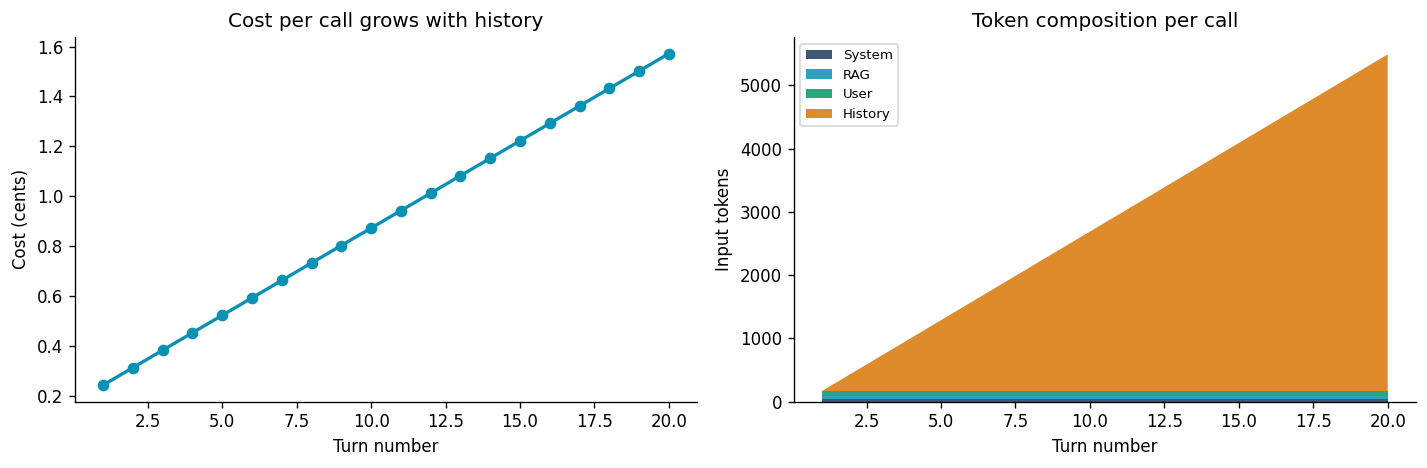

Turn 1: 0.2420c  |  Turn 10: 0.8720c  |  Turn 20: 1.5720c


In [8]:
#  Input tokens cost $2.50 per million, output tokens cost $10.00 per million.
# The average user message is assumed to be 80 tokens and the average assistant response 200 tokens.
INPUT_PM = 2.50; OUTPUT_PM = 10.00; AVG_U = 80; AVG_A = 200
turns = list(range(1, 21))
costs, hist = [], 0
for t in turns:
    cost = (sys_t+hist+rag_t+AVG_U)/1e6*INPUT_PM + AVG_A/1e6*OUTPUT_PM
    costs.append(cost);
    # After this turn completes, the history grows by 80 + 200 = 280 tokens — the user message and the assistant response that just happened both get added to history,
    hist = hist + AVG_U + AVG_A

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(turns, [c*100 for c in costs], "o-", color="#0891B2", lw=2)
axes[0].set_xlabel("Turn number"); axes[0].set_ylabel("Cost (cents)")
axes[0].set_title("Cost per call grows with history")

sys_l  = [sys_t]*20; rag_l  = [rag_t]*20; msg_l = [AVG_U]*20
hist_l = [(t-1)*(AVG_U+AVG_A) for t in turns]
axes[1].stackplot(turns, sys_l, rag_l, msg_l, hist_l,
    labels=["System","RAG","User","History"],
    colors=["#1E3A5F","#0891B2","#059669","#D97706"], alpha=0.85)
axes[1].set_xlabel("Turn number"); axes[1].set_ylabel("Input tokens")
axes[1].set_title("Token composition per call"); axes[1].legend(loc="upper left",fontsize=8)
plt.tight_layout(); plt.show()
print(f"Turn 1: {costs[0]*100:.4f}c  |  Turn 10: {costs[9]*100:.4f}c  |  Turn 20: {costs[19]*100:.4f}c")


## Building a RAG Pipeline

Retrieval Augmented Generation (RAG) is a technique for improving the responses of Large Language Models (LLMs) by providing them with external knowledge. Instead of relying solely on the information learned during its training, an LLM can access and use relevant information from a custom dataset or knowledge base at inference time.

How RAG works
- 1.  User Query: The user asks a question.
- 2.  Retrieval: The system searches a knowledge base (e.g., a collection of documents) for information relevant to the query. This often involves using vector embeddings to find semantically similar text chunks.
- 3.  Augmentation: The retrieved information (context) is added to the user's original query.
- 4.  Generation: The augmented prompt (query + context) is fed to an LLM, which then generates an answer based on both the original query and the provided context.

Benefits of RAG:
-   Reduces hallucinations by grounding the LLM in factual data.
-   Allows LLMs to use up-to-date information not present in their training data.
-   Enables LLMs to answer questions about specific domains or private data.
-   Provides a degree of explainability, as the retrieved context can be shown to the user.

We will need to install an open-source PDF library capable of splitting, merging, cropping, and transforming the pages of PDF files, and a library for Chroma vector store, which is an embedding data base.

In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings, HuggingFaceEndpoint, ChatHuggingFace
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain_core.output_parsers import StrOutputParser

For a RAG system, we need a knowledge base. This can be a collection of text files, PDFs, web pages, etc. Now let's download a 250 page pdf on Global Economic Prospects published in 2026:

In [4]:
pdf_url = "https://openknowledge.worldbank.org/server/api/core/bitstreams/a9e24256-baf8-45bb-9075-75e437e1d6f7/content"
pdf_filename = "GEP-Jan-2026.pdf"
response = requests.get(pdf_url, stream=True)
with open(pdf_filename, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

In [5]:
loader = PyPDFLoader(pdf_filename)
documents = loader.load()

Let's see the original file.

In [6]:
from IPython.display import IFrame
IFrame(pdf_filename, width=1000, height=500)

### Chunking and embedding

LLMs have a context window limit — if we feed a document longer than the window, it is truncated or causes an error. We therefore split documents into smaller chunks before indexing them.

`RecursiveCharacterTextSplitter` tries to split along natural semantic boundaries first (paragraphs, then sentences, then words) before resorting to arbitrary character splits. Its key parameters are:

- **`chunk_size`**: the maximum size of each chunk in characters. We use 1,000 characters — large enough to preserve context, small enough for precise retrieval.
- **`chunk_overlap`**: how many characters to repeat between adjacent chunks. We use 100 (10% of chunk size). This overlap is important: if a key fact falls at a split boundary, it would be severed across two chunks and neither chunk alone would contain it fully. Overlap ensures it appears completely in at least one chunk.

**Chunking strategy matters**: chunk too small and each chunk loses surrounding context; chunk too large and the embedding vector averages too many topics and retrieval precision falls. Overlap is the standard mitigation for boundary splitting.


In [13]:
text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=100
    )
split_docs = text_splitter.split_documents(documents)

To perform semantic search, we need to convert our text chunks into numerical vectors (embeddings). We'll use a model from Hugging Face via `sentence-transformers`, `all-MiniLM-L6-v2`. This model runs locally. The following code will download the model files the first time it's run.

In [14]:
embedding_model_name = "sentence-transformers/all-MiniLM-L6-v2"
embeddings = HuggingFaceEmbeddings(model_name=embedding_model_name)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

A vector store takes care of storing embedded data and performing vector search. There are many vector store options, and Chroma is one of them, it is free, open-source, and can run entirely on the local machine. Now, let's  create an index which contains all the information. Given that the report is 250 pages, this takes a while.

Vector store can run in-memory, but it also supports persistent storage to disk, making it easier to save and reload data across sessions. Note that if we run the code below multiple times with the same persist directory, we will have duplicate vectors.

In [15]:
vector_store = Chroma.from_documents(documents=split_docs,
                                     # The 250-page report broken into chunks
                                     embedding=embeddings,
                                     # With the model we selected, converts text to vectors (embeddings) per document chunk
                                     collection_metadata={"hnsw:space": "cosine"},
                                     # similarity measurement; i.e., finds vectors pointing to same direction (similar meaning) via cosine (most common)
                                     persist_directory='./rag')
                                     # where the database is saved locally

**How Chroma indexes and searches embeddings**

The `collection_metadata={"hnsw:space": "cosine"}` parameter configures two things:

- **HNSW** (Hierarchical Navigable Small World): the indexing algorithm. HNSW builds a multi-layer graph where vectors that are close in meaning are connected. When a query arrives, it navigates this graph to find approximate nearest neighbours efficiently — without comparing the query vector against every stored vector one by one. This is what makes semantic search fast even across hundreds of thousands of chunks.

- **Cosine distance**: the distance metric used to compare vectors. Note that Chroma returns a **distance score**, not a similarity score. With cosine distance, **lower scores mean more similar** (0.0 = identical direction, 2.0 = opposite direction). This is the inverse of cosine similarity. When you see scores below 0.5 in the retrieval output, that is strong semantic similarity.

Without indexing, a query against 5,000 document chunks would require 5,000 individual cosine comparisons. With HNSW, the relevant chunks are found in milliseconds by traversing the graph.


To load the vector store for querying without re-adding documents, we should uncomment the following code:

In [16]:
# vector_store = Chroma( persist_directory='./rag', embedding_function=embeddings )

We can also create embeddings when not present, and load these otherwise:

In [17]:
# if not os.path.exists('./rag'):
#     vector_store = Chroma.from_documents(
#         documents=split_docs,
#         embedding=embeddings,
#         collection_metadata={"hnsw:space": "cosine"},
#         persist_directory='./rag'
#     )
# else:
#     vector_store = Chroma(
#         persist_directory='./rag',
#         embedding_function=embeddings
#     )

We can check the number of embedding vectors stored and compare it to the number of chunks we have (split_docs variable):

In [18]:
count = len(vector_store.get(include=[])["ids"])

print(f"Vectors stored in Chroma: {count:,}")

Vectors stored in Chroma: 1,138


In [19]:
len(split_docs)

1138

The retriever is responsible for fetching relevant documents from the vector store based on a query. Let's see top 3 chunk that match a sample query:

In [20]:
retriever = vector_store.as_retriever(search_kwargs={"k": 1})
doc_chunk_retrieved = retriever.invoke("What are the main challenges for global trade?")
print(doc_chunk_retrieved[0].page_content)

Globalization of trade and financial flows  
High trade costs: causes and remedies June 2021, chapter 3 
The impact of COVID-19 on global value chains June 2020, box SF1 
Poverty impact of food price shocks and policies January 2019, chapter 4 
Arm’s-length trade: A source of post-crisis trade weakness  June 2017, Special Focus 2 
The U.S. economy and the world January 2017, Special Focus 
Potential macroeconomic implications of the Trans-Pacific Partnership Agreement January 2016, chapter 4 
Regulatory convergence in mega-regional trade agreements January 2016, box 4.1.1 
China’s integration in global supply chains: Review and implications January 2015, box 2.1 
Can remittances help promote consumption stability? January 2015, chapter 4 
What lies behind the global trade slowdown? January 2015, chapter 4


Let's now fetch more results with the similarity scores

In [21]:
sample_query = "What are the main challenges for global trade?"
retrieved_docs_with_scores = vector_store.similarity_search_with_score(sample_query, k=3)

print(f"Query: '{sample_query}'")
print()
for i, (doc, score) in enumerate(retrieved_docs_with_scores):
    print(f"--- Retrieved Document {i+1} ---")
    print(f"  Cosine distance: {score:.4f}  (lower = more similar; 0.0 = identical)")
    print(f"  Source page:     {doc.metadata.get('page', 'N/A')}")
    print(f"  Content preview: {doc.page_content[:300]}...")

Query: 'What are the main challenges for global trade?'

--- Retrieved Document 1 ---
  Cosine distance: 0.3180  (lower = more similar; 0.0 = identical)
  Source page:     237
  Content preview: Globalization of trade and financial flows  
High trade costs: causes and remedies June 2021, chapter 3 
The impact of COVID-19 on global value chains June 2020, box SF1 
Poverty impact of food price shocks and policies January 2019, chapter 4 
Arm’s-length trade: A source of post-crisis trade weakn...
--- Retrieved Document 2 ---
  Cosine distance: 0.3431  (lower = more similar; 0.0 = identical)
  Source page:     53
  Content preview: C H A PT ER  1 G L O B AL  EC ON O M I C PR O SPEC T S |  J AN UA R Y 20 2 6 32 
  could escalate again on account of developments 
unrelated to international trade. 
Additionally, there is a rising risk that tariff 
measures could broaden to third countries. When 
large economies increase tariffs, ...
--- Retrieved Document 3 ---
  Cosine distance: 0.3638  (low

 Chroma with cosine distance returns distance scores, not similarity scores. A score of 0.0 means identical vectors. A score of 2.0 means opposite vectors. Typical good retrieval scores are below 0.4.

### Generation

Generating a final answer from an LLM requires a capable generative model

In [22]:
chat = ChatGoogleGenerativeAI(
    model="models/gemma-3-27b-it",
    temperature=0.1,
    max_output_tokens=300,
    google_api_key=os.getenv("GOOGLE_API_KEY"),
)

Now we will set up a RAG pipeline. It takes an LLM and a retriever. We can also customize the prompt template.

In [23]:
prompt_template = """Use the following pieces of context to answer the question at the end.
If you don't know the answer from the context, just say that you don't know, don't try to make up an answer.
Use three sentences maximum and keep the answer concise. If the context is empty or irrelevant, state that you cannot answer based on the provided information.
Context: {context}
Question: {question}
Helpful Answer:"""

QA_PROMPT = PromptTemplate(
    template=prompt_template, input_variables=["context", "question"]
)

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs) #before we checked just one entry via [0], but here we join all with blank lines between them

retriever = vector_store.as_retriever(search_kwargs={"k": 3})

def rag_chain(question):

    docs = retriever.invoke(question) # retrieve relevant documents

    context = format_docs(docs) # convert doc chunks to plain text

    filled_prompt = QA_PROMPT.invoke({"context": context, "question": question}) # fill the prompt template

    llm_response = chat.invoke(filled_prompt) # send to LLM

    result = StrOutputParser().invoke(llm_response) # extract plain text from LLM response


    return {"result": result, "context": docs}

output = rag_chain("What is the projected global inflation?")
print(output["result"])     # final answer
print()


for doc in output["context"]:  # source documents
    print(doc.page_content)
    print("---")

Global inflation in 2026 is projected to edge down to 2.6 percent, which is 0.3 percentage point lower than previously expected. It has continued to trend closer to central bank targets, despite remaining above pre-pandemic norms. Projected disinflation reflects softening labor markets, subdued demand, and falling energy prices.

alongside weakening labor markets. The adoption 
of new AI-related technologies in some service 
companies appears to have boosted productivity, 
suggesting the potential for further reduction in 
price pressures, particularly in advanced econo- 
mies (Brynjolfsson, Li, and Raymond 2023; 
Gibson 2024; Noy and Zhang 2023).  
Going forward, model-based inflation projections 
show global inflation in 2026 edging down to 2.6 
percent, 0.3 percentage point lower than previous- 
ly expected (refer to figure 1.5.C). However, the 
outlook remains uncertain because of the magni- 
tude and scope of trade policy shifts. In the 
United States, the inflationary impact of t

Let's go through each of the steps below:

- retriever.invoke(question) searches the vector store and returns the most relevant document chunks as a list.
- - format_docs(docs) joins those chunks into a single plain text string, separating them with blank lines so the LLM can read them as continuous context.
QA_PROMPT.invoke({"context": context, "question": question}) fills in the prompt template — inserting the retrieved text and the user's question into the placeholders defined earlier.
- chat.invoke(filled_prompt) sends the complete assembled prompt to the Gemini API and returns the model's response object.
- StrOutputParser().invoke(llm_response) extracts the plain text string from that response object, giving us the final answer.


We can also try a different question:

In [24]:
output = rag_chain("What are some risks to the economic outlook mentioned in the document?")
print(output["result"])     # final answer
print()
#print(output["context"])

for doc in output["context"]:  # source documents
    print(doc.page_content)
    print("---")

Some risks to the economic outlook include increases in trade barriers, softening commodity prices, and unexpected tightening of financial conditions. Climate-related shocks, such as extreme weather events, also pose a risk to vulnerable sectors. Additionally, elevated debt burdens could result in capital outflows.

consumption and investment in several countries. Re storing strong output growth is critical for sustai ning wage 
employment creation and improving job quality. Risks  to the outlook are tilted to the downside. Addition al 
increases in trade barriers and associated uncertainty, or a softening of commodity prices, could dampen exports, 
investment, and fiscal revenues. Given elevated debt  burdens, an unexpected tightening of financial cond itions 
could result in capital outflows, and climate-relate d shocks pose a risk to vulnerable sectors such as agriculture, 
fisheries, and energy. 
Note : This section was prepared by Francisco Arroyo Mar ioli  
and Emiliano Luttini.


## Embedding Space and Semantic Search Properties

When an embedding model encodes a piece of text, it produces a vector — a list of numbers — where the position in that high-dimensional space reflects meaning. Texts that mean similar things end up close together; texts that mean different things end up far apart. Closeness in this space is measured using cosine similarity, which looks at the angle between two vectors rather than the distance between them. A cosine similarity of 1.0 means the vectors point in exactly the same direction — identical meaning — while values closer to 0 indicate increasingly unrelated content.

For this example, we'll use the `all-MiniLM-L6-v2` model. It's a good general-purpose model that maps sentences to a 384-dimensional dense vector space and is known for its speed and quality.

In [25]:
from sentence_transformers import SentenceTransformer
embedder = SentenceTransformer("all-MiniLM-L6-v2")

sentences = [
    "The model generates one token at a time.",
    "How long is the warranty?",
    "My account has been hacked.",
    "The model performed excellently.",
    "MoE reduces inference cost."
]
len(sentences)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


5

Now, we can use the loaded model to encode these sentences into embeddings.

In [26]:
embeddings = embedder.encode(sentences)
embeddings.shape

(5, 384)

We see that each of the 5 sentences is represented as 384-dimensional vector. Let's just check the first few entries of one vector, to confirm it is indeed a dense (most of the entries are not zeros), and not sparse (most of the entries are zeros):

In [27]:
embeddings[0][:20]

array([-0.08713921, -0.06817806, -0.0290341 ,  0.07463527, -0.01193224,
       -0.00244996, -0.03753214,  0.01011792,  0.09465679,  0.00460686,
        0.06582899, -0.05642717,  0.07073046, -0.06734595,  0.04322989,
        0.05445211, -0.05624046, -0.00335702, -0.07069635, -0.06693339],
      dtype=float32)

Now let's see some examples to illustrate that geometric closeness in the embedding space reflects topical or semantic relatedness, but that is not always the same as being relevant to a specific question.

In [28]:
pairs = [
    ("The model generates one token at a time.",
     "Each output token is produced sequentially.", "Paraphrase - relatively higher"),
    ("How long is the warranty?",
     "What is the guarantee period?", "Synonym, diff vocab - relatively higher"),
    ("My account has been hacked.",
     "I cannot log into my account.", "similar topic, but not exact, would not be useful in RAG even if it is similar"),
    ("The model performed excellently.",
     "The model failed on every test.", "antonyms"),
    ("MoE reduces inference cost.",
     "The weather in Lisbon is warm.", "Unrelated - low similarity"),
]
print(f"{'Description':<45} {'Similarity':>12}")
print("-"*59)
for s1, s2, label in pairs:
    e1  = embedder.encode(s1, convert_to_numpy=True)
    e2  = embedder.encode(s2, convert_to_numpy=True)
    sim = cosine_similarity(
        e1.reshape(1, -1),
        e2.reshape(1, -1) )[0][0]
    print(f"{label:<45} {sim:>12.4f}")
    print(f"  A: {s1[:60]}")
    print(f"  B: {s2[:60]}")
    print()


Description                                     Similarity
-----------------------------------------------------------
Paraphrase - relatively higher                      0.6400
  A: The model generates one token at a time.
  B: Each output token is produced sequentially.

Synonym, diff vocab - relatively higher             0.6344
  A: How long is the warranty?
  B: What is the guarantee period?

similar topic, but not exact, would not be useful in RAG even if it is similar       0.5866
  A: My account has been hacked.
  B: I cannot log into my account.

antonyms                                            0.3593
  A: The model performed excellently.
  B: The model failed on every test.

Unrelated - low similarity                          0.0625
  A: MoE reduces inference cost.
  B: The weather in Lisbon is warm.



Now, let's reduce the embeddings to 2 dimensions using t-SNE for visualization purpose.

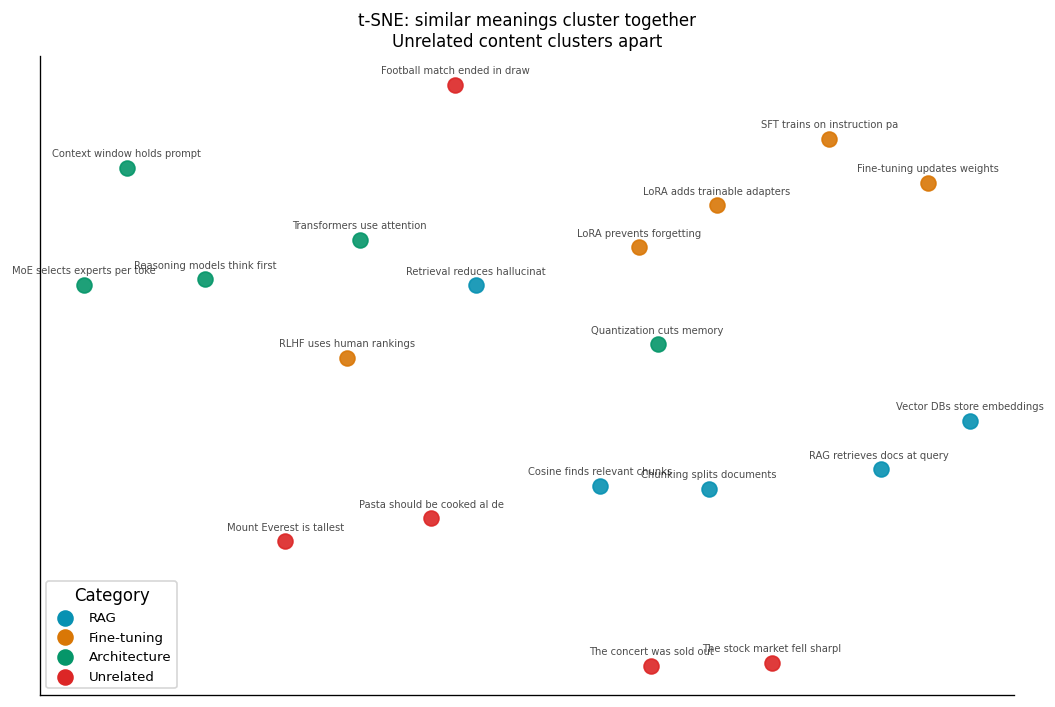

In [29]:
# t-SNE visualisation
from sklearn.manifold import TSNE
sents = {
    "RAG":          ["RAG retrieves docs at query time","Vector DBs store embeddings",
                     "Chunking splits documents","Cosine finds relevant chunks","Retrieval reduces hallucination"],
    "Fine-tuning":  ["LoRA adds trainable adapters","SFT trains on instruction pairs",
                     "RLHF uses human rankings","Fine-tuning updates weights","LoRA prevents forgetting"],
    "Architecture": ["Transformers use attention","MoE selects experts per token",
                     "Quantization cuts memory","Reasoning models think first","Context window holds prompt"],
    "Unrelated":    ["The stock market fell sharply","Pasta should be cooked al dente",
                     "The concert was sold out","Mount Everest is tallest","Football match ended in draw"],
}
all_s, all_l = [], []
for cat, sl in sents.items():
    all_s.extend(sl); all_l.extend([cat]*len(sl))
embs   = embedder.encode(all_s, convert_to_numpy=True)
coords = TSNE(n_components=2, perplexity=5, random_state=42).fit_transform(embs)
colors = {"RAG":"#0891B2","Fine-tuning":"#D97706","Architecture":"#059669","Unrelated":"#DC2626"}
fig, ax = plt.subplots(figsize=(9,6))
for i,(s,l) in enumerate(zip(all_s,all_l)):
    ax.scatter(coords[i,0],coords[i,1],color=colors[l],s=80,zorder=3,alpha=0.9)
    ax.annotate(s[:28],(coords[i,0],coords[i,1]),fontsize=6,alpha=0.7,ha="center",
                xytext=(0,7),textcoords="offset points")
for l,c in colors.items():
    ax.scatter([],[],color=c,label=l,s=80)
ax.legend(title="Category",fontsize=8)
ax.set_title("t-SNE: similar meanings cluster together\nUnrelated content clusters apart",fontsize=10)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


## Prompt Engineering Experiments

Prompt engineering is the practice of structuring your inputs to get better outputs from a language model without changing its weights. The same underlying model can produce very different results depending on how the question is framed, what examples are provided, and what instructions are given. This section runs three concrete experiments to make those differences measurable rather than just theoretical. The first compares zero-shot prompting — simply asking the question — against few-shot prompting, where a handful of examples are provided before the actual query to show the model the desired format. The second tests chain-of-thought prompting, which instructs the model to reason step by step before answering, and measures whether that changes accuracy on arithmetic problems. The third examines the effect of a negative instruction — telling the model to say it does not know rather than guessing — and observes how that changes behavior on questions the model cannot reliably answer.

The first experiment uses a small local model so no API key is required, and the goal is to see the mechanism at work rather than to achieve production-quality results. DistilGPT-2 is a very small model (~82MB) used here purely for demonstration — it is fast and requires no GPU, but its outputs will not be impressive.



In [30]:
from transformers import pipeline, AutoTokenizer
import transformers
import torch
transformers.logging.set_verbosity_error()

MODEL = "distilgpt2"  # Tiny model. Use TinyLlama/TinyLlama-1.1B-Chat-v1.0 for better results.
# Downloads and loads the tokenizer for this model
exp_tok = AutoTokenizer.from_pretrained(MODEL)
# This line tells the tokenizer to use the end-of-sequence token, to avoid error when processing batches of different lengths.
exp_tok.pad_token = exp_tok.eos_token

# Creates a Hugging Face text generation pipeline
gen_pipe = pipeline("text-generation", model=MODEL, tokenizer=exp_tok,
                    device="cuda" if torch.cuda.is_available() else "cpu",
                    pad_token_id=exp_tok.eos_token_id)

print(f"Ready on: {'GPU' if torch.cuda.is_available() else 'CPU'}")

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Ready on: GPU


In [31]:
TASK = "Classify sentiment as POSITIVE, NEGATIVE, or NEUTRAL."
FEW  = ("Review: Fast delivery, works perfectly.\nSentiment: POSITIVE\n\n"
        "Review: Better than expected.\nSentiment: POSITIVE\n\n"
        "Review: Broke after one day.\nSentiment: NEGATIVE\n\n"
        "Review: Does what it says.\nSentiment: NEUTRAL\n\n")
reviews = [
    "The product is amazing.",
    "Terrible quality, broke after one day.",
    "An average product, nothing special.",
]
print("ZERO-SHOT vs FEW-SHOT")
print("="*60)
for r in reviews:
    zs = gen_pipe(f"{TASK}\n\nReview: {r}\nSentiment:", do_sample=True,
              temperature=0.7, return_full_text=False)[0]["generated_text"].strip()

    fs = gen_pipe(f"{TASK}\n\n{FEW}Review: {r}\nSentiment:", do_sample=True,
              temperature=0.7, return_full_text=False)[0]["generated_text"].strip()
    print(f"\nReview: '{r}'")
    print(f"  Zero-shot: {zs[:100]}")
    print(f"  Few-shot:  {fs[:100]}")
    print("="*60)

ZERO-SHOT vs FEW-SHOT

Review: 'The product is amazing.'
  Zero-shot: "Socially responsible"
Review: "Cultural responsible"
Review: "Unconscious"
Review: "Diversity-consc
  Few-shot:  NEGATIVE
Review: Good.
Sentiment: NEGATIVE
Review: NEGATIVE
Review: A great product.
Sentiment: NEGA

Review: 'Terrible quality, broke after one day.'
  Zero-shot: Very poor quality, terrible quality, poor quality, good quality, bad quality.
Review: Poor quality.

  Few-shot:  NEGATIVE
Review: NEGATIVE
Review: NEGATIVE
Review: NEGATIVE
Review: NEGATIVE
Review: BFFTY
Review: G

Review: 'An average product, nothing special.'
  Zero-shot: A product, nothing special.
Sentiment: A product, nothing special.
Sentiment: A product, nothing spe
  Few-shot:  NEUTRAL
Review: Good.
Sentiment: NEGATIVE
Review: Great.
Sentiment: NEGATIVE
Review: Very good.
Sent


Zero-shot is clearly wrong and not even attempting the task. Rather than outputting POSITIVE, NEGATIVE, or NEUTRAL, the model continues the text as if writing a product review itself. This is because distilgpt2 is a base language model — it was trained only to predict the next token, not to follow instructions. When it sees the prompt it treats it as text to continue rather than a task to complete. It has no concept of "classify this."
Few-shot got some labels right but then kept generating additional examples in the same format as the examples you provided. This is actually the few-shot mechanism working correctly — the model learned the pattern of the examples and continued generating more examples in that same format, which is what a next-token predictor naturally does. It produced the right answer first but did not know to stop.

Now, let's see chain of thought prompting. We will use a better model than in the previous example, Geminito see how CoT prompting gives explicit reasoning steps, that are easier to verify.

In [32]:
problems = [
    ("If a model costs $2.50 per million input tokens and you send "
     "500 tokens per call with 10,000 calls per day, what is the daily cost?", "$12.50"),
    ("A context window has 128,000 tokens. The system prompt uses 2,000 tokens. "
     "Each conversation turn averages 300 tokens. How many turns fit before the limit is reached?", "420 turns"),
]
chat = ChatGoogleGenerativeAI(
    model="gemma-3-1b-it",
    temperature=0.1,
    max_output_tokens=1024,
    google_api_key=os.getenv("GOOGLE_API_KEY"),
)

print("DIRECT vs CHAIN-OF-THOUGHT")
print("="*60)
for prob, expected in problems:
    direct_response = chat.invoke(f"Problem: {prob}\nAnswer in one sentence:")
    cot_response    = chat.invoke(f"Problem: {prob}\nThink through this step by step, then give the final answer:")

    direct = direct_response.content if hasattr(direct_response, "content") else str(direct_response)
    cot    = cot_response.content    if hasattr(cot_response, "content")    else str(cot_response)

    print(f"\nProblem: {prob[:80]}...")
    print(f"Expected: {expected}")
    print(f"Direct:\n{direct}")
    print(f"\nCoT:\n{cot}")
    print("-"*60)

DIRECT vs CHAIN-OF-THOUGHT

Problem: If a model costs $2.50 per million input tokens and you send 500 tokens per call...
Expected: $12.50
Direct:
The daily cost is $2.50 per million input tokens, calculated as $2.50 * 500 tokens = $1250.

CoT:
Here's how to calculate the daily cost:

1. **Tokens per call:** 500 tokens/call
2. **Total tokens per day:** 500 tokens/call * 10,000 calls/day = 5,000,000 tokens/day
3. **Cost per token:** $2.50/million tokens
4. **Total cost per day:** 5,000,000 tokens/day * $2.50/token = $12,500,000

Therefore, the daily cost is $12,500,000.

**Final Answer: $12,500,000**
------------------------------------------------------------

Problem: A context window has 128,000 tokens. The system prompt uses 2,000 tokens. Each c...
Expected: 420 turns
Direct:
The system prompt will limit the context window at 128,000 - 2,000 = 126,000 tokens.

CoT:
Okay, let's break this down step-by-step:

1. **Context Window Limit:** The context window has 128,000 tokens.

2. **Sys

CoT does not guarantee correctness — it increases reliability by forcing explicit steps, but the model can still make logical errors within those steps. The system prompt was listed as a relevant fact but then ignored in the calculation.

Negative instructions explicitly tell the model what to do when it lacks reliable knowledge, rather than leaving it to default to generating a plausible-sounding answer.

In [33]:
questions = [
    ("What is the capital of France?",               True,  "Paris"),
    ("Who wrote Hamlet?",                            True,  "Shakespeare"),
    ("What was the AAPL closing price yesterday?",   False, "I don't know"),
    ("What will the weather be in Lisbon tomorrow?", False, "I don't know"),
]
print("WITH vs WITHOUT negative instruction")
print("="*70)
for q, answerable, expected in questions:
    without_r = chat.invoke(f"Answer briefly:\n{q}")
    with_r    = chat.invoke(f"Answer briefly. If you are not certain, say I don't know.\n{q}")

    without = without_r.content if hasattr(without_r, "content") else str(without_r)
    with_i  = with_r.content    if hasattr(with_r,    "content") else str(with_r)

    print(f"\nQ: {q}  (answerable={answerable})")
    print(f"  Without instruction: {without}")
    print(f"  With instruction:    {with_i}")
    print(f"  Expected:            {expected}")

WITH vs WITHOUT negative instruction

Q: What is the capital of France?  (answerable=True)
  Without instruction: Paris.
  With instruction:    Paris.
  Expected:            Paris

Q: Who wrote Hamlet?  (answerable=True)
  Without instruction: William Shakespeare wrote Hamlet.
  With instruction:    William Shakespeare
  Expected:            Shakespeare

Q: What was the AAPL closing price yesterday?  (answerable=False)
  Without instruction: The AAPL closing price yesterday, September 27, 2023, was $172.67.
  With instruction:    I don’t know.
  Expected:            I don't know

Q: What will the weather be in Lisbon tomorrow?  (answerable=False)
  Without instruction: I do not have access to real-time weather information. To find out the weather in Lisbon tomorrow, please check a reliable weather app or website.
  With instruction:    I don’t have real-time weather data. However, the forecast for Lisbon tomorrow is partly cloudy with a high of 22°C and a low of 14°C.
  Expected:      

## Fine-Tuning with LoRA

Fine-tuning adapts a pre-trained model to a specific task by continuing training on a smaller, curated dataset. Rather than training from scratch — which would require enormous data and compute — fine-tuning takes advantage of the rich language understanding already encoded in the pre-trained weights and adjusts them toward the target task.

In this section we fine-tune DistilBERT for multi-class text classification: given a short piece of text, predict which of the six emotions it expresses. We will use the emotions dataset which contains short English text messages — similar in style to tweets or social media posts — each labeled with one of six basic human emotions: sadness, joy, love, anger, fear, and surprise. It was created by researchers at DAIR AI and contains around 20,000 examples collected from social media, making it a realistic representation of how people express emotions in informal written text.

In [34]:
from datasets import load_dataset

# Load the emotions dataset
dataset = load_dataset("dair-ai/emotion", split="train")


from collections import defaultdict
samples_per_class = defaultdict(list)
for item in dataset:
    if len(samples_per_class[item["label"]]) < 20:
        samples_per_class[item["label"]].append(item)
    if all(len(v) == 10 for v in samples_per_class.values()):
        break

data = [item for items in samples_per_class.values() for item in items]

label_names = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}
print(f"Training examples: {len(data)}")
print("Label distribution:")
from collections import Counter
for label, count in Counter(d["label"] for d in data).items():
    print(f"  {label_names[label]}: {count}")

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Training examples: 120
Label distribution:
  sadness: 20
  anger: 20
  love: 20
  surprise: 20
  fear: 20
  joy: 20


In [35]:
from transformers import (DistilBertTokenizer, DistilBertForSequenceClassification,
                          Trainer, TrainingArguments)
from peft import get_peft_model, LoraConfig, TaskType
from datasets import Dataset
import torch
# Load base model
tokenizer  = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
base_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=6)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_model = base_model.to(device)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

We use LoRA (Low-Rank Adaptation) rather than full fine-tuning. Instead of updating all 66 million parameters of DistilBERT, LoRA freezes the base weights entirely and inserts small trainable adapter matrices — updating less than 1% of total parameters. The result is a fine-tuned model that is cheaper to train, faster to iterate on, and does not risk overwriting the general language knowledge the base model already has.

A library which we will use is PEFT, Parameter-Efficient Fine-Tuning, from Hugging Face.

In [36]:
lora_config = LoraConfig(
    # sequence classification task
    task_type=TaskType.SEQ_CLS,
    # A rank of 8 means each adapter adds two small matrices of dimension (original_size × 8) and (8 × original_size).
    r=8,
    # Scaling factor applied to the adapter output before it is added to the frozen weights.
    # Setting alpha to twice the rank is a common default
    lora_alpha=16,
    # Dropout applies a 5% dropout to the adapter activations during training, randomly zeroing out values to prevent overfitting
    lora_dropout=0.05,
    #  specifies which weight matrices inside the model receive LoRA adapters.
    # In DistilBERT's attention mechanism, q_lin is the query projection and v_lin is the value projection.
    # research has shown that adapting the query and value matrices captures most of the task-specific adaptation benefit.
    # The key and output projections are left frozen
    target_modules=["q_lin", "v_lin"],
    # bias terms in the target layers are not trained
    bias="none",
)
lora_model = get_peft_model(base_model, lora_config)

total     = sum(p.numel() for p in lora_model.parameters())
trainable = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
print(f"Total parameters:      {total:,}")
print(f"Trainable (LoRA only): {trainable:,}")
print(f"Trainable fraction:    {trainable/total*100:.3f}%")

Total parameters:      67,700,748
Trainable (LoRA only): 742,662
Trainable fraction:    1.097%


In [37]:
def tokenize(example):
    tokens = tokenizer(example["text"], truncation=True,
                       padding="max_length", max_length=64)
    tokens["labels"] = example["label"]
    return tokens

ds = Dataset.from_list(data).map(tokenize, remove_columns=Dataset.from_list(data).column_names)


# Train
args = TrainingArguments(
    output_dir="./distilbert_lora",
    num_train_epochs=10,
    # batch size of 4
    per_device_train_batch_size=4,
    learning_rate=5e-4,
    logging_steps=3,
    save_strategy="no",
    report_to="none")

trainer = Trainer(model=lora_model, args=args, train_dataset=ds)
trainer.train()

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

{'loss': '1.891', 'grad_norm': '4.951', 'learning_rate': '0.0004967', 'epoch': '0.1'}
{'loss': '1.87', 'grad_norm': '3.107', 'learning_rate': '0.0004917', 'epoch': '0.2'}
{'loss': '1.835', 'grad_norm': '3.195', 'learning_rate': '0.0004867', 'epoch': '0.3'}
{'loss': '1.835', 'grad_norm': '2.6', 'learning_rate': '0.0004817', 'epoch': '0.4'}
{'loss': '1.845', 'grad_norm': '4.683', 'learning_rate': '0.0004767', 'epoch': '0.5'}
{'loss': '1.953', 'grad_norm': '4.04', 'learning_rate': '0.0004717', 'epoch': '0.6'}
{'loss': '1.801', 'grad_norm': '2.462', 'learning_rate': '0.0004667', 'epoch': '0.7'}
{'loss': '1.875', 'grad_norm': '3.221', 'learning_rate': '0.0004617', 'epoch': '0.8'}
{'loss': '1.741', 'grad_norm': '2.32', 'learning_rate': '0.0004567', 'epoch': '0.9'}
{'loss': '1.905', 'grad_norm': '3.403', 'learning_rate': '0.0004517', 'epoch': '1'}
{'loss': '1.745', 'grad_norm': '3.573', 'learning_rate': '0.0004467', 'epoch': '1.1'}
{'loss': '1.68', 'grad_norm': '2.681', 'learning_rate': '0.00

TrainOutput(global_step=300, training_loss=0.7779700926939647, metrics={'train_runtime': 9.2442, 'train_samples_per_second': 129.811, 'train_steps_per_second': 32.453, 'train_loss': 0.7779700926939647, 'epoch': 10.0})

Let's see the loss curve shows that the LoRA fine-tuning. Note that in the plot below, the number of steps is the number of mini batches:
- 120/4=30 mini batches
- 30 mini batche x 10 epochs= 300 steps

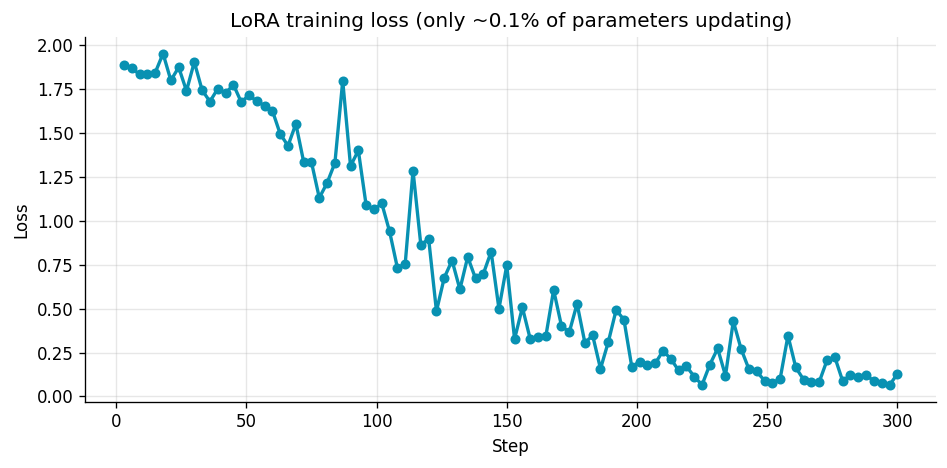

Loss: 1.891 -> 0.128


In [38]:
# Training loss curve
logs  = trainer.state.log_history
steps = [x["step"] for x in logs if "loss" in x]
loss  = [x["loss"] for x in logs if "loss" in x]
if steps:
    fig, ax = plt.subplots(figsize=(8,4))
    ax.plot(steps, loss, "o-", color="#0891B2", lw=2, ms=5)
    ax.set_xlabel("Step"); ax.set_ylabel("Loss")
    ax.set_title("LoRA training loss (only ~0.1% of parameters updating)")
    ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
    print(f"Loss: {loss[0]:.3f} -> {loss[-1]:.3f}")

Now, let's compare the base and fine tuned models on a small test set:

In [39]:
test_reviews = [
    {"text": "i feel so empty inside and nothing makes me smile anymore",      "label": 0, "category": "sadness"},
    {"text": "i am absolutely thrilled about what happened today",              "label": 1, "category": "joy"},
    {"text": "i just adore spending time with this person",                     "label": 2, "category": "love"},
    {"text": "i am so frustrated i could scream right now",                     "label": 3, "category": "anger"},
    {"text": "i feel so nervous i dont know what is going to happen",           "label": 4, "category": "fear"},
    {"text": "i never expected this to happen i am completely shocked",         "label": 5, "category": "surprise"},
]

label_names = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}
base_model_eval = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=6
).to(device)
base_model_eval.eval()

print("BASE MODEL vs LORA FINE-TUNED")
print("="*70)

base_correct, lora_correct = 0, 0

for item in test_reviews:
    inputs = tokenizer(item["text"], return_tensors="pt",
                       truncation=True, max_length=64)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Base model prediction
    with torch.no_grad():
        base_pred = base_model_eval(**inputs).logits.argmax(-1).item()

    # LoRA model prediction
    lora_model.eval()
    with torch.no_grad():
        lora_pred = lora_model(**inputs).logits.argmax(-1).item()

    base_correct += int(base_pred == item["label"])
    lora_correct += int(lora_pred == item["label"])

    print(f"Text:        '{item['text'][:60]}'")
    print(f"Expected:     {item['category']}")
    print(f"Base model:   {label_names[base_pred]}  {'✓' if base_pred == item['label'] else '✗'}")
    print(f"LoRA model:   {label_names[lora_pred]}  {'✓' if lora_pred == item['label'] else '✗'}")
    print()

print(f"Base model accuracy: {base_correct}/{len(test_reviews)}")
print(f"LoRA model accuracy: {lora_correct}/{len(test_reviews)}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

BASE MODEL vs LORA FINE-TUNED
Text:        'i feel so empty inside and nothing makes me smile anymore'
Expected:     sadness
Base model:   sadness  ✓
LoRA model:   sadness  ✓

Text:        'i am absolutely thrilled about what happened today'
Expected:     joy
Base model:   sadness  ✗
LoRA model:   surprise  ✗

Text:        'i just adore spending time with this person'
Expected:     love
Base model:   sadness  ✗
LoRA model:   love  ✓

Text:        'i am so frustrated i could scream right now'
Expected:     anger
Base model:   sadness  ✗
LoRA model:   anger  ✓

Text:        'i feel so nervous i dont know what is going to happen'
Expected:     fear
Base model:   sadness  ✗
LoRA model:   fear  ✓

Text:        'i never expected this to happen i am completely shocked'
Expected:     surprise
Base model:   sadness  ✗
LoRA model:   surprise  ✓

Base model accuracy: 1/6
LoRA model accuracy: 5/6


The base model scores 1 out of 6, essentially random performance as expected for an untrained six-way classifier, while the LoRA fine-tuned model achieves 5 out of 6 on the test set, based on fine tuning on only 120 examples for 742,662 tunable parameters,  less than 1% of the model's parameters. That said this is too small a test set for complete evaluation.

Next, we can save the fine tuned model, as follows:

In [40]:
# Show adapter file size
lora_model.save_pretrained("./distilbert_lora_adapter")
size = sum(os.path.getsize(f"./distilbert_lora_adapter/{f}")
           for f in os.listdir("./distilbert_lora_adapter")
           if os.path.isfile(f"./distilbert_lora_adapter/{f}"))
print(f"\nLoRA adapter size: {size/1024:.1f} KB")
print(f"Base model size:   ~250 MB")
print(f"Adapter is {size/(250*1024*1024)*100:.2f}% of base model size")


LoRA adapter size: 2910.8 KB
Base model size:   ~250 MB
Adapter is 1.14% of base model size


## Key points

- Token costs accumulate across every component of the context window on every API call
- RAG grounds model responses in retrieved documents rather than parametric memory, reducing hallucination and enabling access to private knowledge without retraining
- High cosine similarity measures geometric proximity in the embedding space, not factual relevance — two texts can be very similar vectors while requiring completely different responses
- Few-shot prompting outperforms zero-shot by positioning the model in the correct output distribution through examples, not by teaching it new knowledge
- Chain-of-thought forces explicit intermediate steps that constrain subsequent reasoning, but does not guarantee correctness
- Negative instructions reduce hallucination only where the model has an internal uncertainty signal — they cannot fix cases where the model generates confidently with no awareness of being wrong
- LoRA updates less than 1% of parameters by adding small adapter matrices alongside frozen base weights, avoiding catastrophic forgetting while achieving task-specific adaptation
A decreasing training loss does not guarantee generalisation — a model